# Lezione 7 - Pytorch

- Pytorch
- Classificatore
- Pulizia dei dati

**Gradient Descent:**
Il gradient descent è un algoritmo di ottimizzazione che, partendo da un punto arbitrario sulla curva di errore, calcola iterativamente il gradiente (la pendenza) e aggiorna i pesi di un modello nella direzione di discesa per minimizzare la funzione di costo. Il learning rate stabilisce la dimensione dei passi: valori troppo alti rischiano di “saltare” il minimo, troppo bassi rallentano la convergenza.

Tipi:

Batch Gradient Descent
Aggiorna i pesi solo dopo aver calcolato l’errore sulla totalità del dataset, usando la media dei gradienti di tutti gli esempi in un unico passo per epoca. Questo approccio garantisce un aggiornamento molto regolare e convergenza stabile, ma richiede di caricare l’intero set in memoria e può rimanere bloccato in un minimo locale.

Stochastic Gradient Descent (SGD)
Aggiorna i pesi immediatamente dopo ogni singolo esempio, usando il gradiente calcolato su una sola osservazione in ciascun passo. Grazie a queste frequenti variazioni “rumorose”, SGD è più veloce e può superare piccole trappole locali, ma introduce molta oscillazione nella traiettoria di ottimizzazione.

Mini-batch Gradient Descent
Divide il dataset in piccoli blocchi (p.es. 32 o 64 esempi) e aggiorna i pesi su ognuno di questi mini-batch. In questo modo bilancia la stabilità delle stime di batch con la velocità e il rumore controllato di SGD.


```bash
. venv/bin/activate
pip install torch
pip install torchvision
```

Per questo progetto ci serve torchvision, un'estensione di PyTorch specificamente progettata per задач di visione artificiale. Fornisce in un unico pacchetto:
- **Dataset comuni** pronti da scaricare (es. MNIST, CIFAR, PCam).
- **Funzioni di preprocessing e augmentation** (ridimensionamenti, ritagli, normalizzazioni).
- **Modelli di rete neurale pre-addestrati** (ResNet, VGG, ecc.) che puoi usare direttamente o adattare.
Questo permette di iniziare rapidamente a costruire e addestrare reti per la visione artificiale, senza gestire manualmente download, lettura di file o la definizione da zero delle architetture di base.

In [1]:
import torch
import torchvision # Libreria per la visione artificiale in PyTorch
import torchvision.transforms as transforms # Modulo per le trasformazioni delle immagini

In [2]:
# Impostazione di come verranno elaborate le immagini.
# Questo processo converte le immagini in un formato che il nostro modello di IA può comprendere
# e normalizza i valori dei pixel in un intervallo specifico (generalmente da -1 a 1 o da 0 a 1).
transform = transforms.Compose(
    [transforms.ToTensor(),  # Converte le immagini PIL o NumPy ndarray (H x W x C) nell'intervallo [0, 255]
                             # in tensori PyTorch FloatTensor di forma (C x H x W) nell'intervallo [0.0, 1.0].
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) 
# Normalizza un tensore immagine con media e deviazione standard.
# Dati media: (mean[1],...,mean[n]) e deviazione standard: (std[1],..,std[n]) per n canali,
# questa trasformazione normalizzerà ogni canale dell'input `torch.*Tensor` cioè
# `output[channel] = (input[channel] - mean[channel]) / std[channel]`.
# Qui, per ogni canale, si sottrae 0.5 e si divide per 0.5.
# Questo sposta i valori dei pixel dall'intervallo [0,1] all'intervallo [-1,1].
# La normalizzazione aiuta il modello a convergere più velocemente durante l'addestramento.

# Numero di immagini da elaborare contemporaneamente in un batch.
# Un valore più piccolo richiede meno memoria ma può rallentare l'addestramento.
batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# Caricamento del dataset di addestramento CIFAR-10 (50.000 immagini 32x32 a colori, divise in 10 classi).
# e utilizza 2 processi worker per caricare i dati più velocemente
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

# Simile a quanto sopra, ma ora carichiamo il dataset di test (10.000 immagini diverse)
# Useremo queste immagini per valutare le prestazioni del nostro modello su dati mai visti prima
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2) # Shuffle è False per il test set perché l'ordine non influenza la valutazione

# Queste sono le 10 categorie di oggetti nel nostro dataset
# La nostra IA imparerà a classificare le immagini in queste categorie
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Show Images:

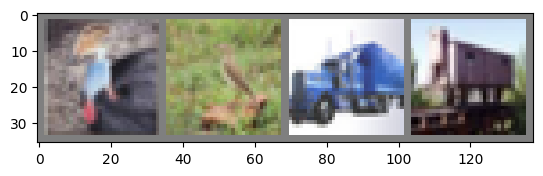

bird  bird  truck truck


In [3]:
import matplotlib.pyplot as plt  # Import matplotlib for creating visualizations
import numpy as np  # Import numpy for numerical operations

# Define a function that displays tensor images by converting them to a viewable format
def imshow(img):
    img = img / 2 + 0.5     # Reverse the normalization we did earlier (from [-1,1] back to [0,1] range)
    npimg = img.numpy()      # Convert PyTorch tensor to NumPy array for matplotlib
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Rearrange dimensions: PyTorch uses [channels, height, width] 
                                                # but matplotlib expects [height, width, channels]
    plt.show()  # Display the image

# Create an iterator from our training data loader
# This lets us extract batches one at a time
dataiter = iter(trainloader)

images, labels = next(dataiter)
# Get one batch of random training images and their labels
# Each batch contains 'batch_size'
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

Let's define a CNN

In [4]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        # Il layer nn.Conv2d(3, 6, 5) prende in input 3 canali 32×32
        # e applica 6 filtri 5×5 con stride=1 e padding=0.
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

Cosa succede in Forward:
| # | Operazione         | Forma (batch × canali × H × W) | Cosa fa                                                                                                                                                                                                                                   |
| - | ------------------ | ------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | `self.conv1(x)`    | **\[B, 6, 28, 28]**            | Applica 6 filtri 5×5 (stride 1, no padding). Ogni filtro calcola una somma pesata locale sui 3 canali RGB e produce una mappa di attivazione.                                                                                             |
| 2 | `F.relu( … )`      | **\[B, 6, 28, 28]**            | Impone la non‑linearità: i valori negativi diventano 0, quelli positivi restano invariati.                                                                                                                                                |
| 3 | `self.pool( … )`   | **\[B, 6, 14, 14]**            | Esegue MaxPool 2×2 (stride 2), scegliendo il valore massimo in ogni finestra non sovrapposta. Dimezza l’altezza e la larghezza, riducendo l’area a un quarto e rendendo la feature map più compatta e leggermente traslazione‑invariante. |
| 4 | Assegnazione a `x` | —                              | Il nuovo tensore sostituisce il valore precedente di `x`, pronto per il prossimo layer (`conv2`).                                                                                                                                         |


Poi


| #  | Istruzione                | Forma in → out                 | Parametri                                              | Cosa succede                                                                                                                                                                           |
| -- | ------------------------- | ------------------------------ | ------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 7  | `x = torch.flatten(x, 1)` | **\[B, 16, 5, 5] → \[B, 400]** | 0                                                      | Ricompone i tre assi (C, H, W) in uno solo. L’argomento `1` indica “comincia a schiacciare dalla dim 1 in poi, lascia intatta la batch (dim 0)”. Il tensore resta contiguo in memoria. |
| 8  | `x = F.relu(self.fc1(x))` | **\[B, 400] → \[B, 120]**      | **W₁ ∈ ℝ^(120×400)**, **b₁ ∈ ℝ¹²⁰** → 48 120 parametri | `fc1` applica l’affinità $\mathbf{z} = \mathbf{W₁x} + \mathbf{b₁}$; `F.relu` impone la non‑linearità $\max(0,z)$.                                                                      |
| 9  | `x = F.relu(self.fc2(x))` | **\[B, 120] → \[B, 84]**       | **W₂ ∈ ℝ^(84×120)**, **b₂ ∈ ℝ⁸⁴** → 10 164 parametri   | Stesso schema: proiezione lineare seguita da ReLU.                                                                                                                                     |
| 10 | `x = self.fc3(x)`         | **\[B, 84] → \[B, 10]**        | **W₃ ∈ ℝ^(10×84)**, **b₃ ∈ ℝ¹⁰** → 850 parametri       | Nessuna attivazione qui: l’output sono **logit** grezzi per 10 classi (ad es. CIFAR‑10).                                                                                               |


3. Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

 Import the 'optim' module from PyTorch, which contains various optimization algorithms.

In [5]:
import torch.optim as optim

Define the loss function.
nn.CrossEntropyLoss is commonly used for multi-class classification problems.
It combines nn.LogSoftmax() and nn.NLLLoss() in one single class.
It measures the difference between the predicted probabilities (output of the network)
and the actual class labels. The goal of training is to minimize this loss.

In [6]:
criterion = nn.CrossEntropyLoss()

Define the optimizer.
optim.SGD stands for Stochastic Gradient Descent, a popular optimization algorithm.
It updates the network's parameters (weights and biases) in the direction
that reduces the loss.
| Argomento                      | Che cos’è / perché serve                                                                                                                                                                                                                         |
| ------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`optim.SGD`**                | *Stochastic Gradient Descent*. Prende i gradienti forniti dal back‑propagation e fa piccoli passi nella direzione opposta (discesa) per ridurre la loss.                                                                                         |
| **`net.parameters()`**         | Un iteratore su **tutti i tensori di peso e bias** del modello `Net`. L’ottimizzatore deve sapere *quali* variabili modificare.                                                                                                                  |
| **`lr=0.001` (learning rate)** | È la **dimensione del passo**. Se è troppo grande rischi di saltare il minimo, se è troppo piccolo impieghi secoli a convergere.                                                                                                                 |
| **`momentum=0.9`**             | Aggiunge un effetto “inerzia”: <br>• accumula una frazione (90 %) dei gradienti passati; <br>• fa sì che i passi abbiano memoria della direzione precedente; <br>• aiuta a superare piccoli ostacoli e linee a zig‑zag nel paesaggio della loss. |


In [7]:
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

4. Train the network
This is when things start to get interesting. We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [8]:
# Itera sul dataset più volte. In questo caso, per 2 epoche.
# Un'epoch è un passaggio completo attraverso l'intero dataset di addestramento.destramento.destramento.
for epoch in range(2):  

    running_loss = 0.0  # Inizializza una variabile per accumulare la perdita a scopo di reporting.
                        # Questa variabile sommerà la perdita di ogni mini-batch e verrà usata per calcolare la perdita media.                        # Questa variabile sommerà la perdita di ogni mini-batch e verrà usata per calcolare la perdita media.                        # Questa variabile sommerà la perdita di ogni mini-batch e verrà usata per calcolare la perdita media.

    # Itera sul 'trainloader', che fornisce batch di dati di addestramento.ento.
    # 'enumerate' aggiunge un contatore 'i' (a partire da 0) ai batch.i batch.
    for i, data in enumerate(trainloader, 0):
        # Get the inputs (images) and labels (true classes) from the current batch.
        inputs, labels = data

        # Zero the parameter gradients.
        # In PyTorch, gradients are accumulated by default. So, before each backward pass,
        # we need to explicitly clear the gradients from the previous iteration.
        optimizer.zero_grad()

        # Forward pass: Pass the input images through the network 'net'.
        # 'outputs' will contain the network's predictions (logits) for each class.
        outputs = net(inputs)
        
        # Calculate the loss: Compare the network's 'outputs' with the true 'labels'
        # using the predefined 'criterion' (e.g., CrossEntropyLoss).
        loss = criterion(outputs, labels)
        
        # Backward pass: Compute the gradients of the loss with respect to all
        # the learnable parameters in the network.
        loss.backward()
        
        # Optimize: Update the network's parameters using the computed gradients.
        # The 'optimizer' (e.g., SGD) adjusts the parameters based on its update rule
        # (e.g., using learning rate and momentum).
        optimizer.step()

        # Print statistics: Accumulate the loss for the current mini-batch.
        # 'loss.item()' gets the scalar value of the loss tensor.
        running_loss += loss.item()
        
        # Print the average loss every 2000 mini-batches.
        # The modulo operator '%' checks if 'i' is one less than a multiple of 2000
        # (e.g., 1999, 3999, 5999, etc.), so it prints after the 2000th, 4000th, etc., mini-batch.
        if i % 2000 == 1999:    
            # Print the epoch number, mini-batch number, and the average loss over the last 2000 mini-batches.
            # The loss is formatted to 3 decimal places.
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            # Reset 'running_loss' to 0 for the next set of mini-batches.
            running_loss = 0.0

# After the loops complete (i.e., all epochs are done), print a message.
print('Finished Training')

[1,  2000] loss: 2.194
[1,  4000] loss: 1.842
[1,  6000] loss: 1.682
[1,  8000] loss: 1.604
[1, 10000] loss: 1.531
[1, 12000] loss: 1.493
[2,  2000] loss: 1.423
[2,  4000] loss: 1.388
[2,  6000] loss: 1.355
[2,  8000] loss: 1.336
[2, 10000] loss: 1.311
[2, 12000] loss: 1.308
Finished Training


Let’s quickly save our trained model:

In [12]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

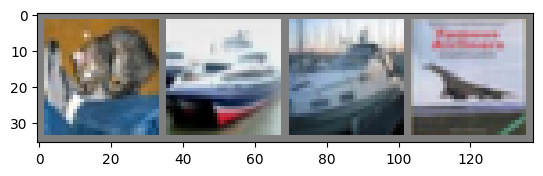

GroundTruth:  cat   ship  ship  plane


In [10]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let’s load back in our saved model (note: saving and re-loading the model wasn’t necessary here, we only did it to illustrate how to do so):

In [14]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are:

In [11]:
outputs = net(images)

The outputs are energies for the 10 classes. The higher the energy for a class, the more the network thinks that the image is of the particular class. So, let’s get the index of the highest energy:

In [12]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   truck car   plane


The results seem pretty good.

Let us look at how the network performs on the whole dataset.

In [13]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

KeyboardInterrupt: 

That looks way better than chance, which is 10% accuracy (randomly picking a class out of 10 classes). Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did not perform well:

In [14]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 62.9 %
Accuracy for class: car   is 53.4 %
Accuracy for class: bird  is 35.7 %
Accuracy for class: cat   is 34.2 %
Accuracy for class: deer  is 45.9 %
Accuracy for class: dog   is 25.1 %
Accuracy for class: frog  is 74.0 %
Accuracy for class: horse is 45.0 %
Accuracy for class: ship  is 59.9 %
Accuracy for class: truck is 82.1 %


Okay, so what next?

How do we run these neural networks on the GPU?

Training on GPU
Just like how you transfer a Tensor onto the GPU, you transfer the neural net onto the GPU.

Let’s first define our device as the first visible cuda device if we have CUDA available:

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

---

# Approfondimenti

## Come funziona il Conv2d(3, 6, 5)

Immagina di avere una riga di 32 pixel (la nostra `H_in = 32`).
Il tuo filtro (`kernel_size = 5`) è come una "finestra" di 5 pixel che scorre su questa riga.

1.  **Senza padding (`padding = 0`) e con `stride = 1`:**
    *   La prima posizione in cui puoi mettere la finestra copre i pixel da 1 a 5.
    *   La seconda posizione copre i pixel da 2 a 6 (perché `stride = 1`, ti sposti di un pixel alla volta).
    *   ...
    *   L'ultima posizione in cui puoi mettere la finestra copre i pixel da 28 a 32.

    Quante posizioni possibili ci sono? Puoi pensarlo come: quanti blocchi di 5 puoi "agganciare" partendo dall'inizio?
    L'ultimo pixel che può essere l'inizio di una finestra è il pixel `32 - 5 + 1 = 28`.
    Quindi ci sono 28 posizioni possibili.

    La formula `(H_in - kernel_size) / stride + 1` generalizza questo:
    *   `H_in - kernel_size`: Questa è l'escursione massima che il *primo pixel* del filtro può avere. Se hai 32 pixel e un filtro di 5, il primo pixel del filtro può andare dalla posizione 1 alla posizione `32-5 = 27`. Questo ti dà `27` possibili *spostamenti* dalla posizione iniziale.
    *   `+ 1`: Devi aggiungere 1 per contare anche la posizione iniziale stessa. Quindi `(32 - 5) + 1 = 28` posizioni.

2.  **Padding (`padding`):**
    Se aggiungessimo del `padding`, ad esempio `padding = 1`, significherebbe aggiungere 1 pixel fittizio (di solito zero) a sinistra e 1 a destra della nostra riga di 32 pixel. La riga diventerebbe lunga `32 + 2*1 = 34` pixel.
    La formula diventa `(H_in - kernel_size + 2*padding)`.
    Nel nostro caso, con `padding = 0`, questo termine non cambia nulla.

3.  **Stride (`stride`):**
    Lo `stride` ti dice di quanti pixel si sposta la finestra ogni volta.
    *   Se `stride = 1`, la finestra si sposta di 1 pixel alla volta.
    *   Se `stride = 2`, si sposta di 2 pixel alla volta, quindi "salterebbe" delle posizioni, e l'output sarebbe più piccolo.
    Ecco perché dividiamo per `stride` nella formula: `(H_in - kernel_size + 2*padding) / stride`.

Quindi, per il tuo `conv1` (`H_in=32`, `kernel_size=5`, `padding=0`, `stride=1`):
`H_out = (32 - 5 + 2*0) / 1 + 1`
`H_out = (27 + 0) / 1 + 1`
`H_out = 27 / 1 + 1`
`H_out = 27 + 1`
`H_out = 28`

Questo calcolo viene fatto sia per l'altezza (`H`) che per la larghezza (`W`). Dato che l'immagine di input è 32x32 e il filtro è 5x5 (quadrato), l'output sarà 28x28.

Il numero `6` in `6x28x28` deriva dal fatto che hai specificato `out_channels=6` in `nn.Conv2d(3, 6, 5)`. Significa che la rete apprende 6 filtri diversi, e ognuno di questi 6 filtri produce una mappa di caratteristiche (feature map) di dimensione 28x28.